# 1. Anti-UAV300 외부 평가 영상 선정

학습 데이터와 다른 환경에서의 일반화 성능 확인을 위한 Anti-UAV300 RGB(visible) 영상 활용

전체 visible 영상 후보 중 일부 영상 무작위 추출 후 초반·중반·후반 프레임 확인

### 선정 기준

- RGB 기반 주간 영상
- UAV 육안 식별 가능 영상
- 하늘·수목·건물 등 다양한 배경 포함
- DUT Anti-UAV와 유사한 소형 UAV 탐지 환경
- 영상 간 배경 및 난이도 차이 고려

### 최종 선정 영상

- `20190925_111757_1_5`
- `20190925_131530_1_2`

전체 visible 영상: 318개
이미 확인한 영상: 110개
남은 영상: 208개
이번 미리보기: 12개
다운로드: 20190926_193515_1_2
Dataset URL: https://www.kaggle.com/datasets/mm1991/anti-uav-dataset-300
다운로드: 20190925_205804_1_8
Dataset URL: https://www.kaggle.com/datasets/mm1991/anti-uav-dataset-300
다운로드: 20190926_144550_1_4
Dataset URL: https://www.kaggle.com/datasets/mm1991/anti-uav-dataset-300
다운로드: 20190926_144550_1_10
Dataset URL: https://www.kaggle.com/datasets/mm1991/anti-uav-dataset-300
다운로드: 20190926_103046_1_7
Dataset URL: https://www.kaggle.com/datasets/mm1991/anti-uav-dataset-300
다운로드: 20190926_141816_1_3
Dataset URL: https://www.kaggle.com/datasets/mm1991/anti-uav-dataset-300
다운로드: 20190925_222534_1_8
Dataset URL: https://www.kaggle.com/datasets/mm1991/anti-uav-dataset-300
다운로드: 20190926_200510_1_8
Dataset URL: https://www.kaggle.com/datasets/mm1991/anti-uav-dataset-300
다운로드: 20190926_195921_1_9
Dataset URL: https://www.kaggle.com/datasets/mm1991/anti-uav-dataset-300
다운로드: 20190926_183400_1_2
Dataset URL: https://

C:\Users\PMS\AppData\Local\Temp\ipykernel_22480\4193427103.py:121: UserWarning: Glyph 52488 (\N{HANGUL SYLLABLE CO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\PMS\AppData\Local\Temp\ipykernel_22480\4193427103.py:121: UserWarning: Glyph 48152 (\N{HANGUL SYLLABLE BAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\PMS\AppData\Local\Temp\ipykernel_22480\4193427103.py:121: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\PMS\AppData\Local\Temp\ipykernel_22480\4193427103.py:121: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\PMS\AppData\Local\Temp\ipykernel_22480\4193427103.py:122: UserWarning: Glyph 52488 (\N{HANGUL SYLLABLE CO}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=150, bbox_inches="tight")
C:\Users\PMS\AppData\Local\Temp\ipykernel_22480\4193427103.py:122: UserWarning: Glyph 48152 (\N{HANGUL 

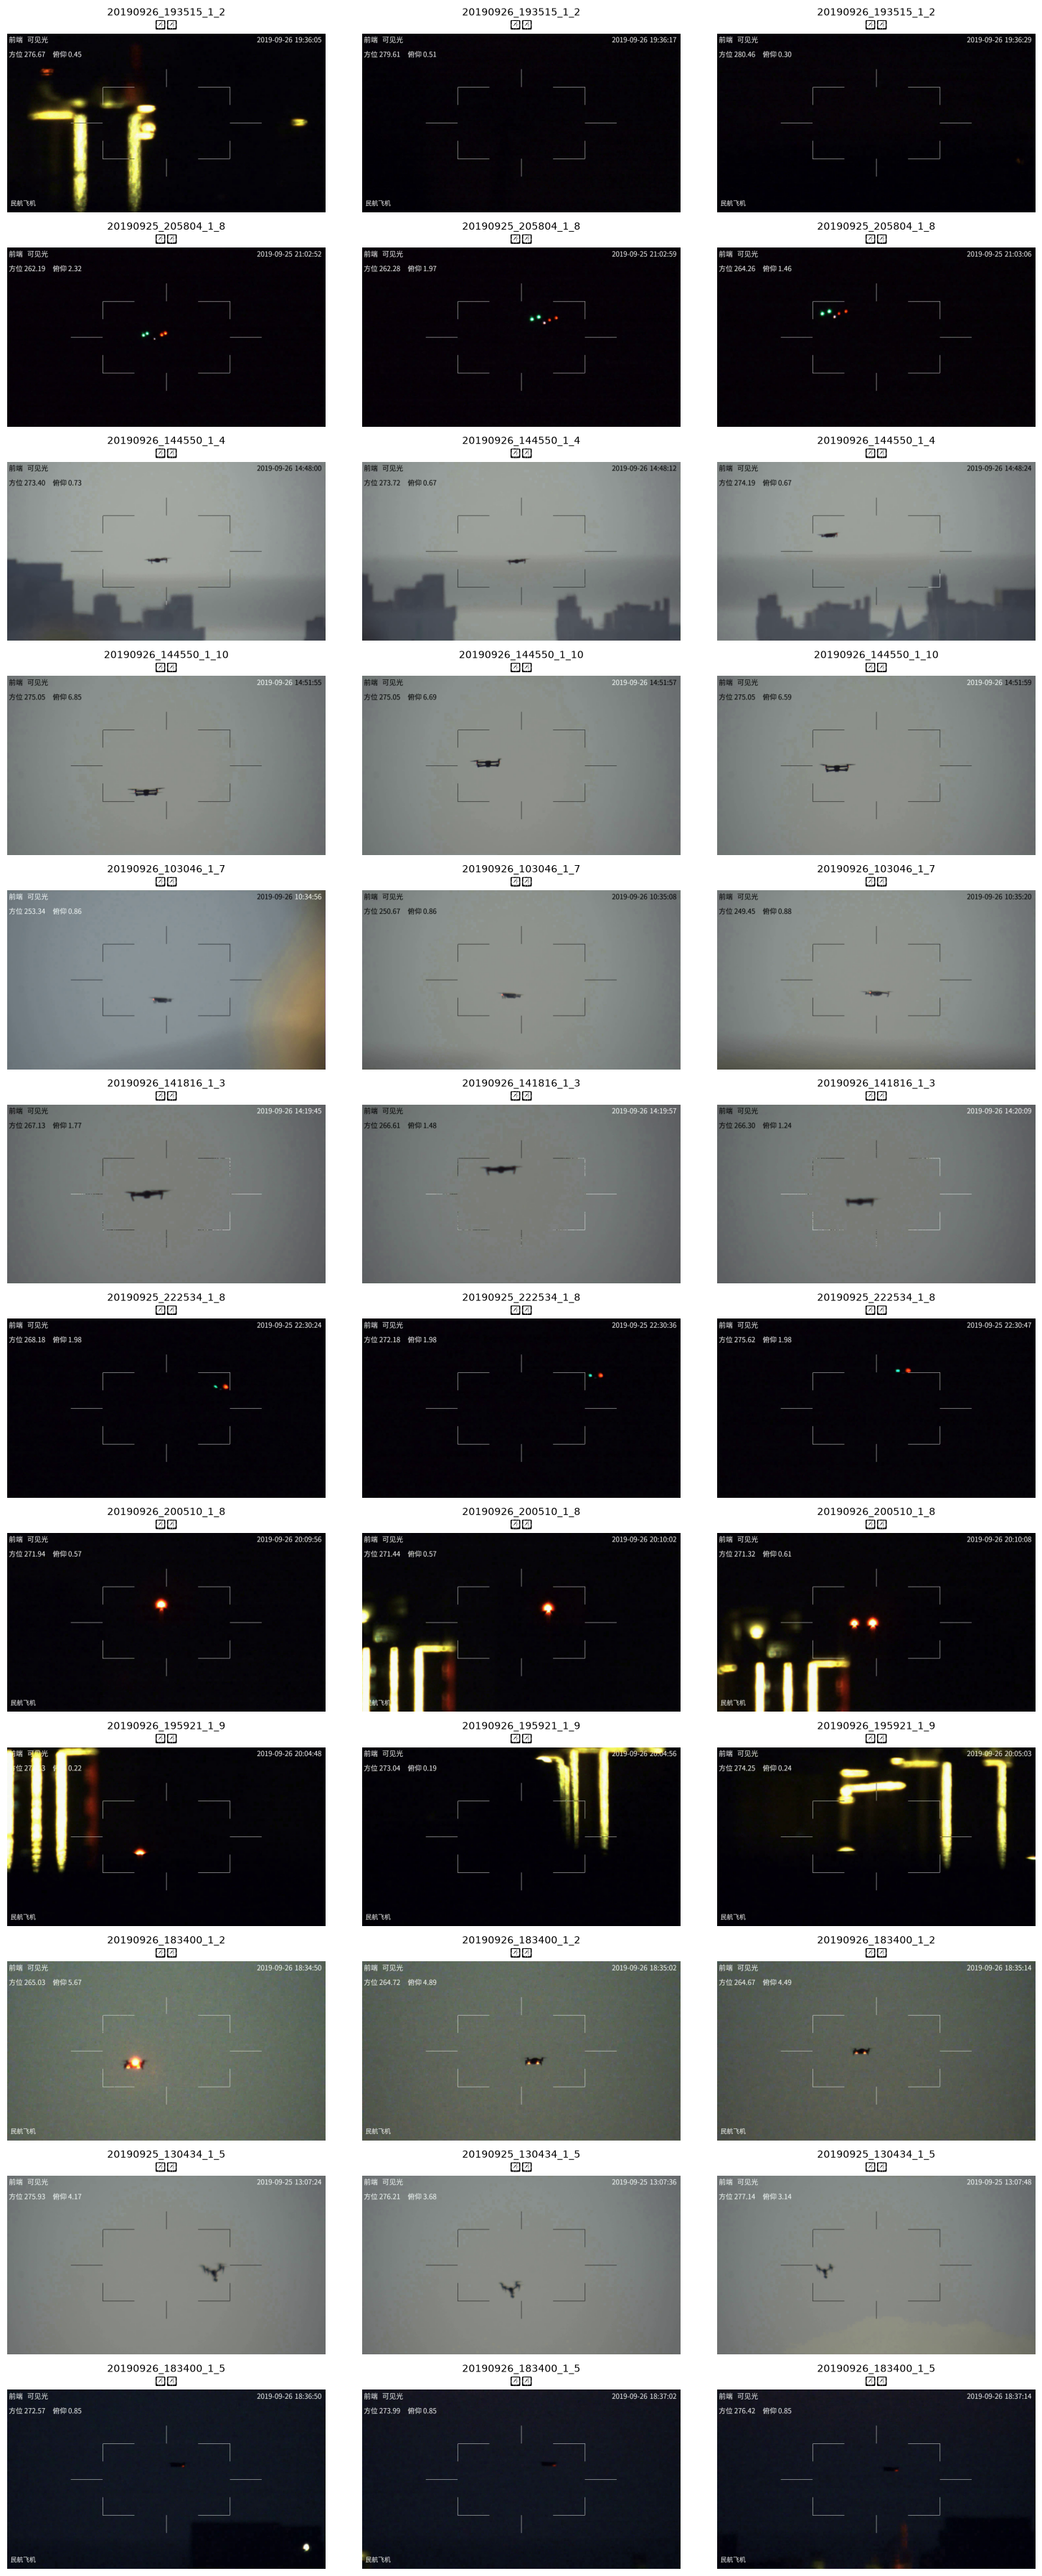

저장 완료: c:\Users\PMS\Desktop\MS\project\small-drone-detection\data\external_preview_result\visible_preview_11.png


In [12]:
from pathlib import Path
import random

import cv2
import matplotlib.pyplot as plt
from kaggle import api


# 경로 및 설정
ROOT = Path.cwd().parent
DATA_DIR = ROOT / "data" / "external_preview"
SAVE_DIR = ROOT / "data" / "external_preview_result"
USED_FILE = SAVE_DIR / "used_sequences.txt"

DATASET = "mm1991/anti-uav-dataset-300"
VIDEO_COUNT = 12
FRAME_POINTS = [0.2, 0.5, 0.8]
FRAME_LABELS = ["초반", "중반", "후반"]


# 전체 visible 영상 목록
def get_videos():
    videos = []
    page_token = None

    while True:
        result = api.dataset_list_files(DATASET, page_token=page_token, page_size=200)

        for file in result.files:
            name = file.name.replace("\\", "/")
            if name.endswith("visible.mp4"):
                videos.append(name)

        page_token = result.next_page_token
        if not page_token:
            break

    return videos


# 영상 다운로드
def download_video(video_file):
    sequence = Path(video_file).parent.name
    folder = DATA_DIR / sequence
    video_path = folder / "visible.mp4"

    if video_path.exists():
        return sequence, video_path

    folder.mkdir(parents=True, exist_ok=True)
    print(f"다운로드: {sequence}")
    api.dataset_download_file(DATASET, video_file, str(folder))

    found = list(folder.rglob("visible.mp4"))
    if not found:
        raise FileNotFoundError(f"다운로드 실패: {sequence}")

    return sequence, found[0]


# 영상의 특정 위치 프레임 추출
def get_frame(video_path, ratio):
    cap = cv2.VideoCapture(str(video_path))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(total * ratio))
    ok, frame = cap.read()
    cap.release()

    return cv2.cvtColor(frame, cv2.COLOR_BGR2RGB) if ok else None


# 미리보기 생성
def main():
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    SAVE_DIR.mkdir(parents=True, exist_ok=True)

    videos = get_videos()
    used = set(USED_FILE.read_text(encoding="utf-8").splitlines()) if USED_FILE.exists() else set()

    # 이미 본 영상 제외
    unused = []
    for video in videos:
        if Path(video).parent.name not in used:
            unused.append(video)

    # 전체 후보에서 무작위 12개 선택
    random.shuffle(unused)
    selected = unused[:VIDEO_COUNT]

    print(f"전체 visible 영상: {len(videos)}개")
    print(f"이미 확인한 영상: {len(used)}개")
    print(f"남은 영상: {len(unused)}개")
    print(f"이번 미리보기: {len(selected)}개")

    if not selected:
        print("새로 확인할 영상이 없습니다.")
        return

    fig, axes = plt.subplots(len(selected), 3, figsize=(15, len(selected)*3))
    if len(selected) == 1:
        axes = [axes]

    # 영상별 초반 / 중반 / 후반
    for i, video_file in enumerate(selected):
        sequence, video_path = download_video(video_file)
        used.add(sequence)

        for j, ratio in enumerate(FRAME_POINTS):
            frame = get_frame(video_path, ratio)

            if frame is not None:
                axes[i][j].imshow(frame)

            axes[i][j].set_title(f"{sequence}\n{FRAME_LABELS[j]}", fontsize=10)
            axes[i][j].axis("off")

    # 결과 저장
    number = len(list(SAVE_DIR.glob("visible_preview_*.png"))) + 1
    save_path = SAVE_DIR / f"visible_preview_{number:02d}.png"

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

    USED_FILE.write_text("\n".join(sorted(used)), encoding="utf-8")
    print(f"저장 완료: {save_path}")


main()

# 2. Anti-UAV300 외부 영상 모델 성능 비교
`src/06_video_test.py` 실행 결과로 저장된 모델별 외부 영상 평가 지표를 불러와  
Baseline, V1, V2의 Precision, Recall, F1, TP, FP, FN, IoU 및 추론 속도를 영상별로 비교

In [ ]:
from pathlib import Path
import pandas as pd


# 모델별 결과 폴더
ROOT = Path.cwd().parent

MODEL_DIRS = {
    "Baseline": ROOT / "models" / "baseline" / "external_test",
    "V1": ROOT / "models" / "improved_v1" / "external_test",
    "V2": ROOT / "models" / "improved_v2" / "external_test",
}


# txt 결과 읽기
def load_metrics(txt_path, model_name):
    data = {"모델": model_name}

    for line in txt_path.read_text(encoding="utf-8").splitlines():
        if ":" not in line:
            continue

        key, value = line.split(":", 1)
        key, value = key.strip(), value.strip()

        if key == "영상":
            data["영상"] = value
        elif key in ["TP", "FP", "FN"]:
            data[key] = int(value)
        elif key in ["Precision", "Recall", "F1"]:
            data[key] = float(value)
        elif key == "평균 TP IoU":
            data["평균 IoU"] = float(value)
        elif key == "평균 추론시간":
            data["추론시간(ms)"] = float(value.split()[0])
        elif key == "추론 FPS":
            data["FPS"] = float(value)

    return data


# 3개 모델 결과 불러오기
rows = []

for model_name, folder in MODEL_DIRS.items():
    for txt_path in folder.glob("*_metrics.txt"):
        rows.append(load_metrics(txt_path, model_name))

compare_df = pd.DataFrame(rows)
compare_df = compare_df.sort_values(["영상", "모델"]).reset_index(drop=True)

display(compare_df.round(4))